# IMPORTING NECESSARY LIBRARIES

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.impute import SimpleImputer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import jaccard_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import lightgbm as lgb

# LOADING DATASET

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df=pd.read_csv('/content/drive/My Drive/exp1_14drivers_14cars_dailyRoutes.csv')
df.head()

<ipython-input-3-9ff4fb462c27>:1: DtypeWarning: Columns (1,2,4,5,6,9,10,14,15,16,20,21,22,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/drive/My Drive/exp1_14drivers_14cars_dailyRoutes.csv')


,TIMESTAMP,MARK,MODEL,CAR_YEAR,ENGINE_POWER,AUTOMATIC,VEHICLE_ID,BAROMETRIC_PRESSURE(KPA),ENGINE_COOLANT_TEMP,FUEL_LEVEL,...,THROTTLE_POS,DTC_NUMBER,TROUBLE_CODES,TIMING_ADVANCE,EQUIV_RATIO,MIN,HOURS,DAYS_OF_WEEK,MONTHS,YEAR
0,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"56,9%","1,0%",13.0,16.0,2.0,8.0,2017.0
1,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"56,5%","1,0%",13.0,16.0,2.0,8.0,2017.0
2,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"57,3%","1,0%",13.0,16.0,2.0,8.0,2017.0
3,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"56,5%","1,0%",13.0,16.0,2.0,8.0,2017.0
4,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"56,9%","1,0%",13.0,16.0,2.0,8.0,2017.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60439 entries, 0 to 60438
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TIMESTAMP                    47514 non-null  float64
 1   MARK                         47459 non-null  object 
 2   MODEL                        47459 non-null  object 
 3   CAR_YEAR                     47459 non-null  float64
 4   ENGINE_POWER                 47459 non-null  object 
 5   AUTOMATIC                    47459 non-null  object 
 6   VEHICLE_ID                   47514 non-null  object 
 7   BAROMETRIC_PRESSURE(KPA)     10212 non-null  float64
 8   ENGINE_COOLANT_TEMP          33964 non-null  float64
 9   FUEL_LEVEL                   2994 non-null   object 
 10  ENGINE_LOAD                  30972 non-null  object 
 11  AMBIENT_AIR_TEMP             3619 non-null   float64
 12  ENGINE_RPM                   33859 non-null  float64
 13  INTAKE_MANIFOLD_

# DATA PREPROCESSING

In [5]:
df = df.drop_duplicates()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47515 entries, 0 to 47514
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TIMESTAMP                    47514 non-null  float64
 1   MARK                         47459 non-null  object 
 2   MODEL                        47459 non-null  object 
 3   CAR_YEAR                     47459 non-null  float64
 4   ENGINE_POWER                 47459 non-null  object 
 5   AUTOMATIC                    47459 non-null  object 
 6   VEHICLE_ID                   47514 non-null  object 
 7   BAROMETRIC_PRESSURE(KPA)     10212 non-null  float64
 8   ENGINE_COOLANT_TEMP          33964 non-null  float64
 9   FUEL_LEVEL                   2994 non-null   object 
 10  ENGINE_LOAD                  30972 non-null  object 
 11  AMBIENT_AIR_TEMP             3619 non-null   float64
 12  ENGINE_RPM                   33859 non-null  float64
 13  INTAKE_MANIFOLD_PRESS

In [7]:
df_with_trouble_codes = df[df['TROUBLE_CODES'].notna()]

In [8]:
print(f"Number of rows with trouble codes: {len(df_with_trouble_codes)}")
print(df_with_trouble_codes['TROUBLE_CODES'].value_counts())  # See top codes

Number of rows with trouble codes: 11925
TROUBLE_CODES
P0133              6070
C0300              5673
P0079P2004P3000      48
P0079C1004P3000      30
P0078U1004P3000      29
P007EP2036P18D0      20
P007EP2036P18E0      18
P0078B0004P3000      12
P007EP2036P18F0       9
P007FP2036P18E0       5
P0079P1004P3000       5
P007FP2036P18D0       3
P007FP2036P18F0       3
Name: count, dtype: int64


In [9]:
df_faulty = df[df['DTC_NUMBER'].str.contains("ON", na=False)]

In [10]:
df['DTC_NUMBER'].unique()

array(['MIL is OFF0 codes', nan, 'MIL is OFF107 codes',
       'MIL is ON0 codes', 'MIL is OFF65 codes', 'MIL is OFF1 codes',
       'MIL is OFF16 codes', 'MIL is OFF8 codes'], dtype=object)

In [11]:
percent_cols = ['ENGINE_LOAD', 'SHORT TERM FUEL TRIM BANK 1', 'THROTTLE_POS', 'TIMING_ADVANCE']
for col in percent_cols:
    df[col] = df[col].str.replace('%', '').str.replace(',', '.').astype(float)

In [12]:
# Drop columns with >30% missing (except TROUBLE_CODES)
threshold = 0.3 * len(df)
df_cleaned = df.dropna(thresh=threshold, axis=1)

In [13]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47515 entries, 0 to 47514
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TIMESTAMP                    47514 non-null  float64
 1   MARK                         47459 non-null  object 
 2   MODEL                        47459 non-null  object 
 3   CAR_YEAR                     47459 non-null  float64
 4   ENGINE_POWER                 47459 non-null  object 
 5   AUTOMATIC                    47459 non-null  object 
 6   VEHICLE_ID                   47514 non-null  object 
 7   ENGINE_COOLANT_TEMP          33964 non-null  float64
 8   ENGINE_LOAD                  30972 non-null  float64
 9   ENGINE_RPM                   33859 non-null  float64
 10  INTAKE_MANIFOLD_PRESSURE     25089 non-null  float64
 11  FUEL_TYPE                    20005 non-null  object 
 12  AIR_INTAKE_TEMP              34352 non-null  float64
 13  SPEED                

In [14]:
#if 'TROUBLE_CODES' not in df_cleaned.columns:
 #   df_cleaned['TROUBLE_CODES'] = df['TROUBLE_CODES']

In [15]:
# Step 2: Extract number of DTCs
df['NUM_DTC'] = df['DTC_NUMBER'].str.extract(r'(\d+)').astype(float)

In [16]:
# Step 3: Check non-null values per column for rows with TROUBLE_CODES
df_with_trouble_codes = df[df['TROUBLE_CODES'].notna()].copy()

In [17]:
df_with_trouble_codes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11925 entries, 17633 to 47275
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TIMESTAMP                    11925 non-null  float64
 1   MARK                         11925 non-null  object 
 2   MODEL                        11925 non-null  object 
 3   CAR_YEAR                     11925 non-null  float64
 4   ENGINE_POWER                 11925 non-null  object 
 5   AUTOMATIC                    11925 non-null  object 
 6   VEHICLE_ID                   11925 non-null  object 
 7   BAROMETRIC_PRESSURE(KPA)     0 non-null      float64
 8   ENGINE_COOLANT_TEMP          11873 non-null  float64
 9   FUEL_LEVEL                   0 non-null      object 
 10  ENGINE_LOAD                  11089 non-null  float64
 11  AMBIENT_AIR_TEMP             0 non-null      float64
 12  ENGINE_RPM                   11837 non-null  float64
 13  INTAKE_MANIFOLD_P

In [18]:
# Step 3: Build df_labeled from original df
df_labeled = df[df['TROUBLE_CODES'].notna()].copy()

In [19]:
df_labeled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11925 entries, 17633 to 47275
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TIMESTAMP                    11925 non-null  float64
 1   MARK                         11925 non-null  object 
 2   MODEL                        11925 non-null  object 
 3   CAR_YEAR                     11925 non-null  float64
 4   ENGINE_POWER                 11925 non-null  object 
 5   AUTOMATIC                    11925 non-null  object 
 6   VEHICLE_ID                   11925 non-null  object 
 7   BAROMETRIC_PRESSURE(KPA)     0 non-null      float64
 8   ENGINE_COOLANT_TEMP          11873 non-null  float64
 9   FUEL_LEVEL                   0 non-null      object 
 10  ENGINE_LOAD                  11089 non-null  float64
 11  AMBIENT_AIR_TEMP             0 non-null      float64
 12  ENGINE_RPM                   11837 non-null  float64
 13  INTAKE_MANIFOLD_P

In [20]:
# Step 4: Drop columns from df and df_labeled based on df_labeled missingness
threshold = 0.3 * len(df_labeled)
cols_to_drop = df_labeled.columns[df_labeled.isnull().sum() > threshold]

In [21]:
df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')
df_labeled = df_labeled.drop(columns=cols_to_drop, errors='ignore')

In [22]:
df_labeled

,TIMESTAMP,MARK,MODEL,CAR_YEAR,ENGINE_POWER,AUTOMATIC,VEHICLE_ID,ENGINE_COOLANT_TEMP,ENGINE_LOAD,ENGINE_RPM,...,THROTTLE_POS,DTC_NUMBER,TROUBLE_CODES,TIMING_ADVANCE,MIN,HOURS,DAYS_OF_WEEK,MONTHS,YEAR,NUM_DTC
17633,1.499536e+12,volkswagen,polo,2006.0,"1,6",n,car6,42.0,6.3,1659.0,...,4.0,MIL is OFF1 codes,P0133,71.4,53.0,18.0,5.0,7.0,2017.0,1.0
17634,1.499536e+12,volkswagen,polo,2006.0,"1,6",n,car6,42.0,6.7,1290.0,...,4.0,MIL is OFF1 codes,P0133,69.0,53.0,18.0,5.0,7.0,2017.0,1.0
17635,1.499537e+12,volkswagen,polo,2006.0,"1,6",n,car6,43.0,7.5,1002.0,...,4.0,MIL is OFF1 codes,P0133,50.6,53.0,18.0,5.0,7.0,2017.0,1.0
17636,1.499537e+12,volkswagen,polo,2006.0,"1,6",n,car6,44.0,5.5,872.0,...,4.0,MIL is OFF1 codes,P0133,53.7,53.0,18.0,5.0,7.0,2017.0,1.0
17637,1.499537e+12,volkswagen,polo,2006.0,"1,6",n,car6,45.0,5.1,856.0,...,3.0,MIL is OFF1 codes,P0133,54.1,53.0,18.0,5.0,7.0,2017.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47266,1.505181e+12,citroen,c3,2013.0,"1,4",n,car13,NaN,22.7,2147.0,...,17.0,MIL is OFF0 codes,P0079P2004P3000,39.6,33.0,1.0,1.0,9.0,2017.0,0.0
47270,1.505181e+12,citroen,c3,2013.0,"1,4",n,car13,92.0,55.7,2508.0,...,25.0,MIL is OFF0 codes,P0078U1004P3000,59.6,33.0,1.0,1.0,9.0,2017.0,0.0
47272,1.505181e+12,citroen,c3,2013.0,"1,4",n,car13,92.0,48.6,2535.0,...,24.0,MIL is OFF0 codes,P007EP2036P18D0,63.9,33.0,1.0,1.0,9.0,2017.0,0.0
47273,1.505181e+12,citroen,c3,2013.0,"1,4",n,car13,92.0,60.8,2390.0,...,25.0,MIL is OFF0 codes,P0078U1004P3000,61.2,33.0,1.0,1.0,9.0,2017.0,0.0


In [23]:
columns_to_restore = ['ENGINE_LOAD', 'INTAKE_MANIFOLD_PRESSURE']

for col in columns_to_restore:
    if col not in df_cleaned.columns and col in df.columns:
        df_cleaned[col] = df[col]
    if col not in df_labeled.columns and col in df.columns:
        df_labeled[col] = df[col]

In [24]:
code_map = {
    'P0133': 'Fuel System Issue',
    'C0300': 'Ignition Problem',

    'P0079P2004P3000': 'Valve Timing / Intake Control Issue',
    'P0079C1004P3000': 'Valve Timing / Intake Control Issue',
    'P0078U1004P3000': 'Valve Timing / Intake Control Issue',
    'P0078B0004P3000': 'Valve Timing / Intake Control Issue',
    'P0079P1004P3000': 'Valve Timing / Intake Control Issue',

    'P007EP2036P18D0': 'Valve Timing / Intake Control Issue',
    'P007EP2036P18E0': 'Valve Timing / Intake Control Issue',
    'P007EP2036P18F0': 'Valve Timing / Intake Control Issue',
    'P007FP2036P18D0': 'Valve Timing / Intake Control Issue',
    'P007FP2036P18E0': 'Valve Timing / Intake Control Issue',
    'P007FP2036P18F0': 'Valve Timing / Intake Control Issue',
}

In [25]:
df_labeled['PROBLEM_TYPE'] = df_labeled['TROUBLE_CODES'].map(code_map)
df_labeled = df_labeled[df_labeled['PROBLEM_TYPE'].notna()]

In [26]:
df_labeled

,TIMESTAMP,MARK,MODEL,CAR_YEAR,ENGINE_POWER,AUTOMATIC,VEHICLE_ID,ENGINE_COOLANT_TEMP,ENGINE_LOAD,ENGINE_RPM,...,DTC_NUMBER,TROUBLE_CODES,TIMING_ADVANCE,MIN,HOURS,DAYS_OF_WEEK,MONTHS,YEAR,NUM_DTC,PROBLEM_TYPE
17633,1.499536e+12,volkswagen,polo,2006.0,"1,6",n,car6,42.0,6.3,1659.0,...,MIL is OFF1 codes,P0133,71.4,53.0,18.0,5.0,7.0,2017.0,1.0,Fuel System Issue
17634,1.499536e+12,volkswagen,polo,2006.0,"1,6",n,car6,42.0,6.7,1290.0,...,MIL is OFF1 codes,P0133,69.0,53.0,18.0,5.0,7.0,2017.0,1.0,Fuel System Issue
17635,1.499537e+12,volkswagen,polo,2006.0,"1,6",n,car6,43.0,7.5,1002.0,...,MIL is OFF1 codes,P0133,50.6,53.0,18.0,5.0,7.0,2017.0,1.0,Fuel System Issue
17636,1.499537e+12,volkswagen,polo,2006.0,"1,6",n,car6,44.0,5.5,872.0,...,MIL is OFF1 codes,P0133,53.7,53.0,18.0,5.0,7.0,2017.0,1.0,Fuel System Issue
17637,1.499537e+12,volkswagen,polo,2006.0,"1,6",n,car6,45.0,5.1,856.0,...,MIL is OFF1 codes,P0133,54.1,53.0,18.0,5.0,7.0,2017.0,1.0,Fuel System Issue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47266,1.505181e+12,citroen,c3,2013.0,"1,4",n,car13,NaN,22.7,2147.0,...,MIL is OFF0 codes,P0079P2004P3000,39.6,33.0,1.0,1.0,9.0,2017.0,0.0,Valve Timing / Intake Control Issue
47270,1.505181e+12,citroen,c3,2013.0,"1,4",n,car13,92.0,55.7,2508.0,...,MIL is OFF0 codes,P0078U1004P3000,59.6,33.0,1.0,1.0,9.0,2017.0,0.0,Valve Timing / Intake Control Issue
47272,1.505181e+12,citroen,c3,2013.0,"1,4",n,car13,92.0,48.6,2535.0,...,MIL is OFF0 codes,P007EP2036P18D0,63.9,33.0,1.0,1.0,9.0,2017.0,0.0,Valve Timing / Intake Control Issue
47273,1.505181e+12,citroen,c3,2013.0,"1,4",n,car13,92.0,60.8,2390.0,...,MIL is OFF0 codes,P0078U1004P3000,61.2,33.0,1.0,1.0,9.0,2017.0,0.0,Valve Timing / Intake Control Issue


In [27]:
print(df_labeled['PROBLEM_TYPE'].value_counts())
print("Final shape of df_labeled:", df_labeled.shape)

PROBLEM_TYPE
Fuel System Issue                      6070
Ignition Problem                       5673
Valve Timing / Intake Control Issue     182
Name: count, dtype: int64
Final shape of df_labeled: (11925, 24)


In [28]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47515 entries, 0 to 47514
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TIMESTAMP                 47514 non-null  float64
 1   MARK                      47459 non-null  object 
 2   MODEL                     47459 non-null  object 
 3   CAR_YEAR                  47459 non-null  float64
 4   ENGINE_POWER              47459 non-null  object 
 5   AUTOMATIC                 47459 non-null  object 
 6   VEHICLE_ID                47514 non-null  object 
 7   ENGINE_COOLANT_TEMP       33964 non-null  float64
 8   ENGINE_LOAD               30972 non-null  float64
 9   ENGINE_RPM                33859 non-null  float64
 10  INTAKE_MANIFOLD_PRESSURE  25089 non-null  float64
 11  AIR_INTAKE_TEMP           34352 non-null  float64
 12  SPEED                     46529 non-null  float64
 13  THROTTLE_POS              33859 non-null  float64
 14  DTC_NUMBER 

In [29]:
shared_features = [
    'ENGINE_COOLANT_TEMP', 'ENGINE_RPM', 'ENGINE_LOAD', 'AIR_INTAKE_TEMP',
    'INTAKE_MANIFOLD_PRESSURE', 'SHORT TERM FUEL TRIM BANK 1', 'THROTTLE_POS',
    'CAR_YEAR', 'MIN', 'HOURS', 'DAYS_OF_WEEK', 'MONTHS', 'YEAR'
]

In [30]:
# Make sure all shared features are in df_cleaned and df_labeled
for col in shared_features:
    if col not in df_cleaned.columns and col in df.columns:
        df_cleaned[col] = df[col]
    if col not in df_labeled.columns and col in df.columns:
        df_labeled[col] = df[col]


In [31]:
# Use median imputation to handle missing values
imputer = SimpleImputer(strategy='median')

In [32]:
df_cleaned[shared_features] = imputer.fit_transform(df_cleaned[shared_features])
df_labeled[shared_features] = imputer.transform(df_labeled[shared_features])

In [33]:
# Create reduced datasets
df_detect = df_cleaned[shared_features].copy()
df_classify = df_labeled[shared_features + ['PROBLEM_TYPE']].copy()

In [34]:
df_classifier = df_labeled[shared_features + ['PROBLEM_TYPE']].copy()

In [35]:
df_detect.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47515 entries, 0 to 47514
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ENGINE_COOLANT_TEMP          47515 non-null  float64
 1   ENGINE_RPM                   47515 non-null  float64
 2   ENGINE_LOAD                  47515 non-null  float64
 3   AIR_INTAKE_TEMP              47515 non-null  float64
 4   INTAKE_MANIFOLD_PRESSURE     47515 non-null  float64
 5   SHORT TERM FUEL TRIM BANK 1  47515 non-null  float64
 6   THROTTLE_POS                 47515 non-null  float64
 7   CAR_YEAR                     47515 non-null  float64
 8   MIN                          47515 non-null  float64
 9   HOURS                        47515 non-null  float64
 10  DAYS_OF_WEEK                 47515 non-null  float64
 11  MONTHS                       47515 non-null  float64
 12  YEAR                         47515 non-null  float64
dtypes: float64(13)
memory

In [36]:
df_classify.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11925 entries, 17633 to 47275
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ENGINE_COOLANT_TEMP          11925 non-null  float64
 1   ENGINE_RPM                   11925 non-null  float64
 2   ENGINE_LOAD                  11925 non-null  float64
 3   AIR_INTAKE_TEMP              11925 non-null  float64
 4   INTAKE_MANIFOLD_PRESSURE     11925 non-null  float64
 5   SHORT TERM FUEL TRIM BANK 1  11925 non-null  float64
 6   THROTTLE_POS                 11925 non-null  float64
 7   CAR_YEAR                     11925 non-null  float64
 8   MIN                          11925 non-null  float64
 9   HOURS                        11925 non-null  float64
 10  DAYS_OF_WEEK                 11925 non-null  float64
 11  MONTHS                       11925 non-null  float64
 12  YEAR                         11925 non-null  float64
 13  PROBLEM_TYPE     

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_detect)
X_class_scaled = scaler.transform(df_classify[shared_features])

# CREATING DETECTION MODEL

ISOLATION FOREST

In [38]:
iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_preds = iso.fit_predict(X_scaled)
df_detect['IF_Anomaly'] = (iso_preds == -1).astype(int)

DBSCAN

In [39]:
k = 4
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

In [40]:
k_distances = distances[:, k-1]
k_distances = np.sort(k_distances)

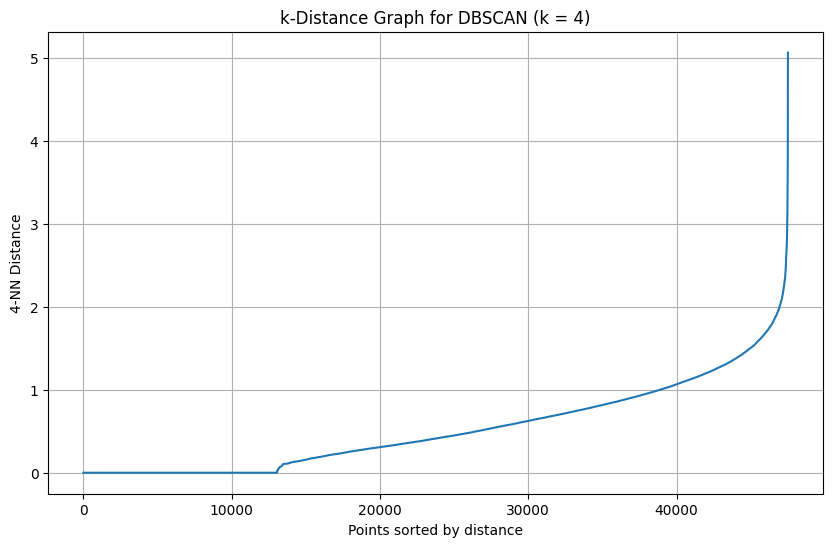

In [41]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title("k-Distance Graph for DBSCAN (k = 4)")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-NN Distance")
plt.grid(True)
plt.show()

In [42]:
db = DBSCAN(eps=1.5, min_samples=5)
db_preds = db.fit_predict(X_scaled)
df_detect['DBSCAN_Anomaly'] = (db_preds == -1).astype(int)

LSTM

In [43]:
# Reshape for LSTM: (samples, timesteps, features)
X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

In [44]:
# Define LSTM autoencoder
model = Sequential([
    LSTM(64, activation='relu', input_shape=(1, X_scaled.shape[1]), return_sequences=True),
    LSTM(32, activation='relu', return_sequences=False),
    RepeatVector(1),
    LSTM(32, activation='relu', return_sequences=True),
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(X_scaled.shape[1]))
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [45]:
model.compile(optimizer='adam', loss='mse')
model.fit(X_lstm, X_lstm, epochs=60, batch_size=32, verbose=0)

In [46]:
X_reconstructed = model.predict(X_lstm)
recon_error = tf.keras.backend.mean(tf.keras.backend.abs(X_lstm - X_reconstructed), axis=(1, 2)).numpy()

1485/1485 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [47]:
# Set threshold at 95th percentile
threshold = np.percentile(recon_error, 95)
df_detect['LSTM_Anomaly'] = (recon_error > threshold).astype(int)

ENSEMBLE

In [48]:
df_detect['Anomaly_Score'] = (
    df_detect['IF_Anomaly'] +
    df_detect['DBSCAN_Anomaly'] +
    df_detect['LSTM_Anomaly']
)

In [49]:
# Flag as consensus anomaly if at least 2 models agree
df_detect['Consensus_Anomaly'] = (df_detect['Anomaly_Score'] >= 2).astype(int)

In [50]:
methods = ['IF_Anomaly', 'DBSCAN_Anomaly', 'LSTM_Anomaly', 'Consensus_Anomaly']

In [51]:
print("Anomaly counts by method:")
for m in methods:
    count = df_detect[m].sum()
    print(f"{m}: {count} ({count / len(df_detect) * 100:.2f}%)")

Anomaly counts by method:
IF_Anomaly: 2376 (5.00%)
DBSCAN_Anomaly: 1744 (3.67%)
LSTM_Anomaly: 2376 (5.00%)
Consensus_Anomaly: 1471 (3.10%)


In [52]:
jaccard = jaccard_score(df_detect['IF_Anomaly'], df_detect['LSTM_Anomaly'])
print(f"Jaccard Similarity: {jaccard:.4f}")

Jaccard Similarity: 0.2565


In [53]:
jaccard2 = jaccard_score(df_detect['IF_Anomaly'], df_detect['DBSCAN_Anomaly'])
print(f"Jaccard Similarity: {jaccard2:.4f}")

Jaccard Similarity: 0.1959


In [54]:
jaccard3 = jaccard_score(df_detect['LSTM_Anomaly'], df_detect['DBSCAN_Anomaly'])
print(f"Jaccard Similarity: {jaccard3:.4f}")

Jaccard Similarity: 0.2111


# CREATING CLASSIFICATION MODEL

In [55]:
# Encode original labels
le_aug = LabelEncoder()
y_encoded_aug = le_aug.fit_transform(df_classifier['PROBLEM_TYPE'])

In [56]:
# Create a noisy version of the dataset
df_noisy_classifier_aug = df_classifier.copy()

In [57]:
# Add Gaussian noise to numeric columns
numeric_cols_aug = df_noisy_classifier_aug.select_dtypes(include=[np.number]).columns
noise_factor_aug = 0.05  # 5% of feature range
df_noisy_classifier_aug[numeric_cols_aug] += noise_factor_aug * np.random.normal(loc=0.0, scale=1.0, size=df_noisy_classifier_aug[numeric_cols_aug].shape)

In [58]:
# Create feature/label set
X_aug = df_noisy_classifier_aug[shared_features].copy()
y_aug = y_encoded_aug

In [59]:
# Flip 5% of the labels
flip_fraction_aug = 0.05
num_to_flip_aug = int(flip_fraction_aug * len(y_aug))
flip_indices_aug = np.random.choice(len(y_aug), size=num_to_flip_aug, replace=False)

# Get unique classes
classes_aug = np.unique(y_aug)

# Flip each label to a different class
for idx in flip_indices_aug:
    current_class = y_aug[idx]
    other_classes = [cls for cls in classes_aug if cls != current_class]
    y_aug[idx] = np.random.choice(other_classes)


In [60]:
# Apply SMOTE before split to increase data for all classes
smote_all = SMOTE(random_state=42)
X_augmented, y_augmented = smote_all.fit_resample(X_aug, y_aug)

In [61]:
# Confirm new class distribution
from collections import Counter
print("Class distribution after SMOTE augmentation:")
print(Counter(y_augmented))

Class distribution after SMOTE augmentation:
Counter({np.int64(0): 5918, np.int64(1): 5918, np.int64(2): 5918})


In [62]:
y_augmented_labels = le_aug.inverse_transform(y_augmented)

In [63]:
# Split into train/test
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_augmented, y_augmented, test_size=0.2, random_state=42, stratify=y_augmented)

In [64]:
scaler_aug = StandardScaler()
X_train_scaled_aug = scaler_aug.fit_transform(X_train_aug)
X_test_scaled_aug = scaler_aug.transform(X_test_aug)

In [65]:
# Train classifier
clf_aug = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf_aug.fit(X_train_scaled_aug, y_train_aug)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [66]:
# Predict
y_pred_aug = clf_aug.predict(X_test_scaled_aug)

In [67]:
y_test_labels_aug = le_aug.inverse_transform(y_test_aug)
y_pred_labels_aug = le_aug.inverse_transform(y_pred_aug)


In [68]:
# Report
print("✅ Classification Report with full dataset SMOTE augmentation:")
print(classification_report(y_test_labels_aug, y_pred_labels_aug))

✅ Classification Report with full dataset SMOTE augmentation:
                                     precision    recall  f1-score   support

                  Fuel System Issue       0.95      0.98      0.96      1183
                   Ignition Problem       0.95      0.97      0.96      1184
Valve Timing / Intake Control Issue       0.99      0.94      0.97      1184

                           accuracy                           0.96      3551
                          macro avg       0.96      0.96      0.96      3551
                       weighted avg       0.96      0.96      0.96      3551



In [71]:
accuracy_aug = accuracy_score(y_test_aug, y_pred_aug)
print(f"Accuracy: {accuracy_aug:.4f}")

Accuracy: 0.9617


XGBoost

In [73]:
# Train XGBoost model
xgb_clf = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_clf.fit(X_train_scaled_aug, y_train_aug)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:06:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [74]:
# Predict
y_pred_xgb = xgb_clf.predict(X_test_scaled_aug)

In [75]:
y_pred_labels_xgb = le_aug.inverse_transform(y_pred_xgb)
y_test_labels_aug = le_aug.inverse_transform(y_test_aug)

In [76]:
# Report
print("📊 Classification Report (XGBoost):")
print(classification_report(y_test_labels_aug, y_pred_labels_xgb))

📊 Classification Report (XGBoost):
                                     precision    recall  f1-score   support

                  Fuel System Issue       0.95      0.97      0.96      1183
                   Ignition Problem       0.95      0.96      0.95      1184
Valve Timing / Intake Control Issue       0.98      0.94      0.96      1184

                           accuracy                           0.96      3551
                          macro avg       0.96      0.96      0.96      3551
                       weighted avg       0.96      0.96      0.96      3551



In [82]:
accuracy_xgb = accuracy_score(y_test_aug, y_pred_xgb)
print(f"Accuracy: {accuracy_xgb:.4f}")

Accuracy: 0.9586


LightBGM

In [79]:
# Train LightGBM model
lgb_clf = lgb.LGBMClassifier(random_state=42)
lgb_clf.fit(X_train_scaled_aug, y_train_aug)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003894 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 14203, number of used features: 13
[LightGBM] [Info] Start training from score -1.098471
[LightGBM] [Info] Start training from score -1.098683
[LightGBM] [Info] Start training from score -1.098683


LGBMClassifier(random_state=42)

In [80]:
# Predict
y_pred_lgb = lgb_clf.predict(X_test_scaled_aug)
y_pred_labels_lgb = le_aug.inverse_transform(y_pred_lgb)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [81]:
# Report
print("📊 Classification Report (LightGBM):")
print(classification_report(y_test_labels_aug, y_pred_labels_lgb))

📊 Classification Report (LightGBM):
                                     precision    recall  f1-score   support

                  Fuel System Issue       0.94      0.97      0.96      1183
                   Ignition Problem       0.94      0.96      0.95      1184
Valve Timing / Intake Control Issue       0.98      0.93      0.95      1184

                           accuracy                           0.95      3551
                          macro avg       0.95      0.95      0.95      3551
                       weighted avg       0.95      0.95      0.95      3551



In [84]:
accuracy_lgb = accuracy_score(y_test_aug, y_pred_lgb)
print(f"Accuracy: {accuracy_lgb:.4f}")

Accuracy: 0.9538


# EXPORTING BOTH MODELS

In [86]:
import joblib

# Save Random Forest classifier components
joblib.dump(clf_aug, 'final_rf_classifier.pkl')

['final_rf_classifier.pkl']

In [87]:
joblib.dump(scaler_aug, 'rf_scaler.pkl')

['rf_scaler.pkl']

In [88]:
joblib.dump(le_aug, 'rf_label_encoder.pkl')

['rf_label_encoder.pkl']

In [89]:
joblib.dump(iso, 'isolation_forest_model.pkl')

['isolation_forest_model.pkl']

In [90]:
joblib.dump(db, 'dbscan_model.pkl')

['dbscan_model.pkl']

In [95]:
joblib.dump(scaler, 'anomaly_scaler.pkl')

['anomaly_scaler.pkl']

In [94]:
model.save('lstm_autoencoder_model.keras')

In [96]:
from google.colab import files
files.download('final_rf_classifier.pkl')
files.download('rf_scaler.pkl')
files.download('rf_label_encoder.pkl')
files.download('isolation_forest_model.pkl')
files.download('dbscan_model.pkl')
files.download('anomaly_scaler.pkl')
files.download('lstm_autoencoder_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>